# Chatbot Conversation Logs Analysis

This notebook analyzes chatbot conversation logs to understand:
1. Time range of the data
2. Message frequency and quantity patterns per user
3. Conversation groupings
4. Query classification (well-specified vs. mispecified)

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from openai import OpenAI
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
# Load the conversation logs
df = pd.read_csv('chatbot_conversation_logs.csv')
print(f"Total records: {len(df):,}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Total records: 12,805

Columns: ['user_id', 'user_age', 'edd', 'lmp', 'location_state', 'sender', 'from', 'to', 'message_timestamp', 'message_date', 'message']


,user_id,user_age,edd,lmp,location_state,sender,from,to,message_timestamp,message_date,message
0,916000152485,27.0,6/26/2026,NaN,Assam,USER,916000152485,918071279667,1/7/2026 5:43:55,1/7/2026,ModerkhatASHA
1,916000152485,27.0,6/26/2026,NaN,Assam,BOT,918071279667,916000152485,1/7/2026 5:43:58,1/7/2026,"Hi there! 👋 I'm Nivi, here to support you on y..."
2,916000152485,27.0,6/26/2026,NaN,Assam,BOT,918071279667,916000152485,1/7/2026 5:43:59,1/7/2026,🟢⚪️⚪️⚪️\n\nआप किस भाषा में चैट करना चाहेंगे? न...
3,916000152485,27.0,6/26/2026,NaN,Assam,USER,916000152485,918071279667,1/7/2026 5:44:12,1/7/2026,3
4,916000152485,27.0,6/26/2026,NaN,Assam,BOT,918071279667,916000152485,1/7/2026 5:44:14,1/7/2026,🟢🟢🟢⚪️ \n\nআপোনাৰ বয়স কিমান?\n{{18 বছৰ}}\n{{19...


## 1. Time Range Analysis

In [3]:
# Convert message_timestamp to datetime
df['message_timestamp'] = pd.to_datetime(df['message_timestamp'], format='%m/%d/%Y %H:%M:%S')
df['message_date'] = pd.to_datetime(df['message_date'], format='%m/%d/%Y')

# Time range analysis
min_date = df['message_timestamp'].min()
max_date = df['message_timestamp'].max()
date_range = max_date - min_date

print("="*60)
print("TIME RANGE ANALYSIS")
print("="*60)
print(f"Earliest message: {min_date}")
print(f"Latest message: {max_date}")
print(f"Date range: {date_range.days} days ({date_range.days / 30:.1f} months)")
print(f"\nTotal messages: {len(df):,}")
print(f"Messages per day (avg): {len(df) / max(date_range.days, 1):.1f}")

TIME RANGE ANALYSIS
Earliest message: 2025-12-04 23:54:38
Latest message: 2026-01-25 16:28:53
Date range: 51 days (1.7 months)

Total messages: 12,805
Messages per day (avg): 251.1


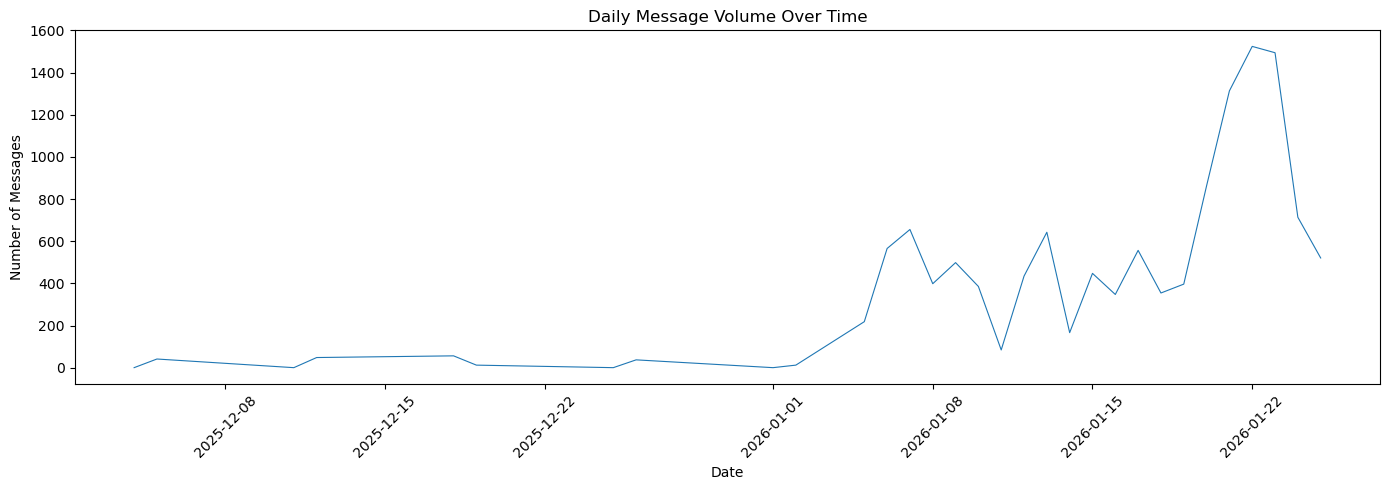


Daily message statistics:
  Min: 1
  Max: 1524
  Mean: 413.1
  Median: 386.0


In [4]:
# Messages over time
daily_messages = df.groupby(df['message_date'].dt.date).size()

plt.figure(figsize=(14, 5))
plt.plot(daily_messages.index, daily_messages.values, linewidth=0.8)
plt.title('Daily Message Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Messages')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nDaily message statistics:")
print(f"  Min: {daily_messages.min()}")
print(f"  Max: {daily_messages.max()}")
print(f"  Mean: {daily_messages.mean():.1f}")
print(f"  Median: {daily_messages.median():.1f}")

## 2. Per-User Message Frequency and Quantity Analysis

In [5]:
# Basic user statistics
unique_users = df['user_id'].nunique()
print("="*60)
print("USER OVERVIEW")
print("="*60)
print(f"Total unique users: {unique_users:,}")

USER OVERVIEW
Total unique users: 389


In [6]:
# Per-user message analysis
user_stats = df.groupby('user_id').agg({
    'message': 'count',
    'message_timestamp': ['min', 'max'],
    'sender': lambda x: (x == 'USER').sum()  # Count user messages only
}).reset_index()

user_stats.columns = ['user_id', 'total_messages', 'first_message', 'last_message', 'user_messages']
user_stats['bot_messages'] = user_stats['total_messages'] - user_stats['user_messages']
user_stats['active_duration_days'] = (user_stats['last_message'] - user_stats['first_message']).dt.days
user_stats['messages_per_day'] = user_stats['total_messages'] / user_stats['active_duration_days'].replace(0, 1)

print("\nPer-user message statistics:")
print(f"  Total messages - Mean: {user_stats['total_messages'].mean():.1f}, Median: {user_stats['total_messages'].median():.1f}")
print(f"  User messages - Mean: {user_stats['user_messages'].mean():.1f}, Median: {user_stats['user_messages'].median():.1f}")
print(f"  Bot messages - Mean: {user_stats['bot_messages'].mean():.1f}, Median: {user_stats['bot_messages'].median():.1f}")
print(f"  Active duration (days) - Mean: {user_stats['active_duration_days'].mean():.1f}, Median: {user_stats['active_duration_days'].median():.1f}")


Per-user message statistics:
  Total messages - Mean: 32.9, Median: 27.0
  User messages - Mean: 9.9, Median: 7.0
  Bot messages - Mean: 23.1, Median: 19.0
  Active duration (days) - Mean: 6.8, Median: 3.0


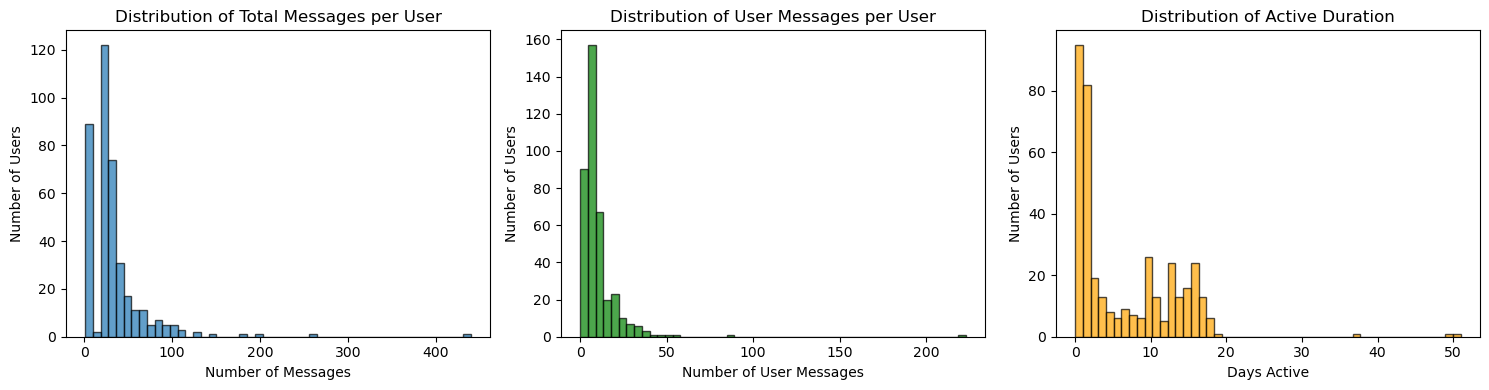

In [7]:
# Distribution of messages per user
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Total messages distribution
axes[0].hist(user_stats['total_messages'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Total Messages per User')
axes[0].set_xlabel('Number of Messages')
axes[0].set_ylabel('Number of Users')

# User messages distribution
axes[1].hist(user_stats['user_messages'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Distribution of User Messages per User')
axes[1].set_xlabel('Number of User Messages')
axes[1].set_ylabel('Number of Users')

# Active duration distribution
axes[2].hist(user_stats['active_duration_days'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[2].set_title('Distribution of Active Duration')
axes[2].set_xlabel('Days Active')
axes[2].set_ylabel('Number of Users')

plt.tight_layout()
plt.show()

In [8]:
# Top users by message count
print("\nTop 10 users by total messages:")
top_users = user_stats.nlargest(10, 'total_messages')[['user_id', 'total_messages', 'user_messages', 'bot_messages', 'active_duration_days']]
print(top_users.to_string(index=False))


Top 10 users by total messages:
     user_id  total_messages  user_messages  bot_messages  active_duration_days
919395059293             440            223           217                     8
917828288021             263             89           174                    51
917002212335             199             52           147                    49
918812099160             178             54           124                    37
916003481510             149             45           104                     9
918638646620             129             36            93                    14
919395617162             124             33            91                     1
917399929510             115             43            72                     4
918770897825             111             40            71                    19
918099531465             110             37            73                    15


In [9]:
# User engagement buckets
def categorize_engagement(msg_count):
    if msg_count <= 5:
        return '1-5 messages (Low)'
    elif msg_count <= 20:
        return '6-20 messages (Medium)'
    elif msg_count <= 50:
        return '21-50 messages (High)'
    else:
        return '50+ messages (Very High)'

user_stats['engagement_level'] = user_stats['total_messages'].apply(categorize_engagement)
engagement_dist = user_stats['engagement_level'].value_counts().sort_index()

print("\nUser Engagement Distribution:")
for level, count in engagement_dist.items():
    pct = count / len(user_stats) * 100
    print(f"  {level}: {count:,} users ({pct:.1f}%)")


User Engagement Distribution:
  1-5 messages (Low): 88 users (22.6%)
  21-50 messages (High): 240 users (61.7%)
  50+ messages (Very High): 57 users (14.7%)
  6-20 messages (Medium): 4 users (1.0%)


## 3. Conversation Grouping and Display

In [10]:
# Group messages into conversations
# A conversation is defined as messages from a user with gaps of less than 30 minutes

def group_into_conversations(user_df, gap_threshold_minutes=30):
    """Group messages into conversations based on time gaps."""
    user_df = user_df.sort_values('message_timestamp')
    
    conversations = []
    current_conversation = []
    last_timestamp = None
    
    for _, row in user_df.iterrows():
        if last_timestamp is None:
            current_conversation.append(row)
        elif (row['message_timestamp'] - last_timestamp).total_seconds() / 60 > gap_threshold_minutes:
            # New conversation
            if current_conversation:
                conversations.append(current_conversation)
            current_conversation = [row]
        else:
            current_conversation.append(row)
        
        last_timestamp = row['message_timestamp']
    
    if current_conversation:
        conversations.append(current_conversation)
    
    return conversations

# Group all conversations
all_conversations = []
for user_id in tqdm(df['user_id'].unique(), desc="Grouping conversations"):
    user_df = df[df['user_id'] == user_id]
    user_conversations = group_into_conversations(user_df)
    for conv in user_conversations:
        all_conversations.append({
            'user_id': user_id,
            'messages': conv,
            'num_messages': len(conv),
            'start_time': conv[0]['message_timestamp'],
            'end_time': conv[-1]['message_timestamp']
        })

print(f"\nTotal conversations identified: {len(all_conversations):,}")
print(f"Average conversations per user: {len(all_conversations) / unique_users:.1f}")

Grouping conversations:   0%|          | 0/389 [00:00<?, ?it/s]

Grouping conversations: 100%|██████████| 389/389 [00:00<00:00, 636.06it/s]


Total conversations identified: 1,515
Average conversations per user: 3.9



Conversation length statistics:
  Min: 1
  Max: 132
  Mean: 8.5
  Median: 1.0


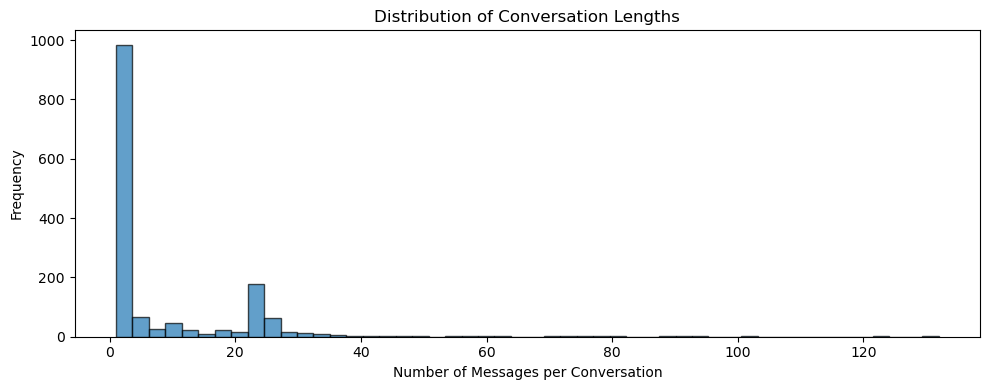

In [11]:
# Conversation statistics
conv_lengths = [c['num_messages'] for c in all_conversations]
print("\nConversation length statistics:")
print(f"  Min: {min(conv_lengths)}")
print(f"  Max: {max(conv_lengths)}")
print(f"  Mean: {np.mean(conv_lengths):.1f}")
print(f"  Median: {np.median(conv_lengths):.1f}")

# Distribution of conversation lengths
plt.figure(figsize=(10, 4))
plt.hist(conv_lengths, bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Conversation Lengths')
plt.xlabel('Number of Messages per Conversation')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [12]:
# Initialize OpenAI client for translations
client = OpenAI()

def translate_to_english(client, text, model_name="gpt-4.1-mini"):
    """
    Translate text to English using GPT. Returns original if already in English.
    """
    prompt = f"""Translate the following text to English. If the text is already in English, return it as-is.
Only return the translated text, nothing else.

Text: "{text}"

Translation:"""

    try:
        response = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.3,
            max_tokens=500
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        print(f"Error translating: {e}")
        return text


## 4. Query Classification: Well-Specified vs. Mispecified

Using GPT 5 mini to classify user queries as well-specified or vague/mispecified.

In [13]:
# Overview of user messages
user_messages_df = df[df['sender'] == 'USER']
print(f"Total user messages: {len(user_messages_df):,}")

Total user messages: 3,836


In [14]:
# Classification function (client and translate_to_english already defined above)

def classify_query_clarity(client, question, model_name="gpt-4.1-mini"):
    """
    Use GPT model to classify if a question is well-specified or vague/mispecified.
    The question should already be translated to English.
    """
    prompt = f"""You are a medical health chatbot answering user's questions about pregnancy. 
Analyze the following question and determine if it's well-specified or too vague/mispecified to answer properly.

Question: "{question}"

Instructions:
- WELL_SPECIFIED: The question is clear, specific, and can be answered accurately. It contains enough context and details.
- MISPECIFIED: The question is too vague, lacks context, is ambiguous, or needs clarification to provide an accurate answer.

Respond with ONLY one word: either "WELL_SPECIFIED" or "MISPECIFIED"

Response:"""

    try:
        response = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.3,
            max_tokens=10
        )
        
        classification = response.choices[0].message.content.strip().upper()
        
        if "WELL_SPECIFIED" in classification:
            return "WELL_SPECIFIED"
        elif "MISPECIFIED" in classification or "VAGUE" in classification:
            return "MISPECIFIED"
        else:
            return "UNCLEAR"
            
    except Exception as e:
        print(f"Error classifying question: {e}")
        return "ERROR"

In [19]:
# Aggressive filtering: >=3 words and unique user queries only
# Create a dataframe with user messages and their indices
df_sorted = df.sort_values(['user_id', 'message_timestamp']).reset_index(drop=True)
user_msg_indices = df_sorted[df_sorted['sender'] == 'USER'].index.tolist()

def get_bot_response_for_user_message(df, user_msg_idx):
    """Find the bot response that follows a user message."""
    for i in range(user_msg_idx + 1, min(user_msg_idx + 5, len(df))):
        if df.iloc[i]['sender'] == 'BOT':
            return df.iloc[i]['message']
    return None

# Build list of ALL user questions with their bot responses
all_questions_with_responses = []
for idx in user_msg_indices:
    user_msg = df_sorted.iloc[idx]['message']
    if not user_msg or not str(user_msg).strip():
        continue
    
    user_id = df_sorted.iloc[idx]['user_id']
    bot_response = get_bot_response_for_user_message(df_sorted, idx)
    
    all_questions_with_responses.append({
        'user_message': str(user_msg),
        'bot_response': str(bot_response) if bot_response else None,
        'user_id': user_id,
        'msg_index': idx
    })

# AGGRESSIVE FILTERING: >= 3 words, unique, and no system messages
filtered_questions = []
seen_messages = set()
short_messages_count = 0
duplicate_messages_count = 0
system_messages_count = 0

for item in all_questions_with_responses:
    user_msg = item['user_message']
    
    # Filter 1: Remove system/navigation messages
    if "GENERIC_SMS_APP" in user_msg:
        system_messages_count += 1
        continue
    
    # Filter 2: Must have >= 3 words
    word_count = len(user_msg.split())
    if word_count < 3:
        short_messages_count += 1
        continue
    
    # Filter 3: Must be unique (case-insensitive)
    normalized_msg = user_msg.lower().strip()
    if normalized_msg in seen_messages:
        duplicate_messages_count += 1
        continue
    
    seen_messages.add(normalized_msg)
    filtered_questions.append(item)

# Print statistics
print("="*60)
print("AGGRESSIVE FILTERING STATISTICS")
print("="*60)
print(f"Total user messages: {len(all_questions_with_responses):,}")
print(f"System messages removed (GENERIC_SMS_APP): {system_messages_count:,}")
print(f"Short messages removed (<3 words): {short_messages_count:,}")
print(f"Duplicate messages removed: {duplicate_messages_count:,}")
print(f"Unique substantive queries remaining: {len(filtered_questions):,}")
total_removed = system_messages_count + short_messages_count + duplicate_messages_count
print(f"Percentage removed: {total_removed / len(all_questions_with_responses) * 100:.1f}%")
print(f"Percentage remaining: {len(filtered_questions) / len(all_questions_with_responses) * 100:.1f}%")

AGGRESSIVE FILTERING STATISTICS
Total user messages: 3,836
System messages removed (GENERIC_SMS_APP): 818
Short messages removed (<3 words): 2,560
Duplicate messages removed: 46
Unique substantive queries remaining: 412
Percentage removed: 89.3%
Percentage remaining: 10.7%



ACTIVE USERS: BEFORE vs AFTER FILTERING
Active users BEFORE filtering: 303
Active users AFTER filtering: 117
Users completely filtered out: 186
User retention rate: 38.6%

PER-USER FILTERED QUERY STATISTICS
Total filtered queries: 412
Average queries per user: 3.5
Median queries per user: 2.0
Max queries from single user: 15
Min queries from single user: 1

Distribution of filtered queries per user:
  1 query: 36 users
  2 queries: 24 users
  3 queries: 11 users
  4 queries: 19 users
  5 queries: 8 users
  6 queries: 4 users
  7 queries: 3 users
  8 queries: 3 users
  10 queries: 2 users
  11 queries: 1 users
  12 queries: 2 users
  13 queries: 2 users
  14 queries: 1 users
  15 queries: 1 users

Top 10 users by filtered query count:
  User 918370097505: 15 queries
  User 919669152450: 14 queries
  User 918099394574: 13 queries
  User 919243659070: 13 queries
  User 917399929510: 12 queries
  User 918770897825: 12 queries
  User 918429015750: 11 queries
  User 918640099790: 10 queries

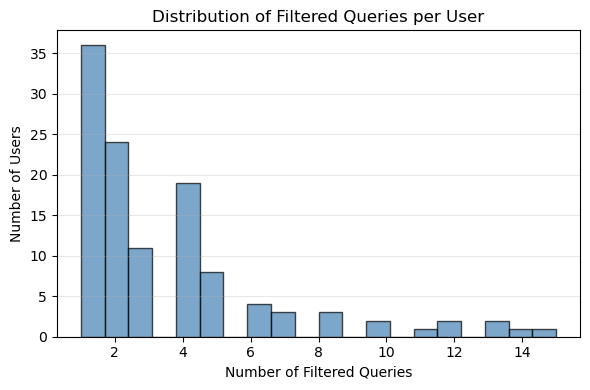

In [30]:
# Per-user statistics: Before and After filtering
from collections import Counter

# Get unique users before and after filtering
users_before = set([item['user_id'] for item in all_questions_with_responses])
users_after = set([item['user_id'] for item in filtered_questions])
users_lost = users_before - users_after

print("\n" + "="*60)
print("ACTIVE USERS: BEFORE vs AFTER FILTERING")
print("="*60)
print(f"Active users BEFORE filtering: {len(users_before):,}")
print(f"Active users AFTER filtering: {len(users_after):,}")
print(f"Users completely filtered out: {len(users_lost):,}")
print(f"User retention rate: {len(users_after) / len(users_before) * 100:.1f}%")

user_query_counts = Counter([item['user_id'] for item in filtered_questions])

print("\n" + "="*60)
print("PER-USER FILTERED QUERY STATISTICS")
print("="*60)
print(f"Total filtered queries: {len(filtered_questions):,}")
print(f"Average queries per user: {len(filtered_questions) / len(user_query_counts):.1f}")
print(f"Median queries per user: {np.median(list(user_query_counts.values())):.1f}")
print(f"Max queries from single user: {max(user_query_counts.values())}")
print(f"Min queries from single user: {min(user_query_counts.values())}")

# Distribution
print("\nDistribution of filtered queries per user:")
query_count_distribution = Counter(user_query_counts.values())
for count in sorted(query_count_distribution.keys()):
    num_users = query_count_distribution[count]
    print(f"  {count} {'query' if count == 1 else 'queries'}: {num_users} users")

# Top 10 users by filtered query count
print("\nTop 10 users by filtered query count:")
top_users = user_query_counts.most_common(10)
for user_id, count in top_users:
    print(f"  User {user_id}: {count} queries")

# Visualization
plt.figure(figsize=(6, 4))

# Distribution histogram
plt.subplot(1, 1, 1)
query_counts = list(user_query_counts.values())
plt.hist(query_counts, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Distribution of Filtered Queries per User')
plt.xlabel('Number of Filtered Queries')
plt.ylabel('Number of Users')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [20]:
# Display sample conversations from filtered questions with 1-hour context

def get_conversation_within_hour(df_sorted, msg_idx):
    """Get all messages within same hour from a user after their query."""
    query_row = df_sorted.iloc[msg_idx]
    user_id = query_row['user_id']
    query_timestamp = query_row['message_timestamp']
    hour_cutoff = query_timestamp + timedelta(hours=1)
    
    # Find all messages from same user within the hour
    messages = []
    for i in range(msg_idx, len(df_sorted)):
        row = df_sorted.iloc[i]
        if row['user_id'] != user_id:
            continue
        if row['message_timestamp'] > hour_cutoff:
            break
        messages.append({
            'sender': row['sender'],
            'message': str(row['message']),
            'timestamp': row['message_timestamp'],
            'is_query': i == msg_idx
        })
    
    return messages

def print_filtered_query_with_context(item, df_sorted, client):
    """Print a filtered query with conversation context within the same hour."""
    user_id = item['user_id']
    msg_idx = item['msg_index']
    user_msg = item['user_message']
    
    print(f"\n{'='*70}")
    print(f"User ID: {user_id}")
    print("-"*70)
    
    messages = get_conversation_within_hour(df_sorted, msg_idx)
    
    for msg in messages:
        message_text = msg['message']
        sender = msg['sender']
        timestamp = msg['timestamp']
        
        # Translate message
        translated = translate_to_english(client, message_text, model_name="gpt-4.1-mini") if len(message_text) > 2 else message_text
        
        prefix = "[USER]" if sender == 'USER' else "[BOT] "
        
        if msg['is_query']:
            print(f"\n{prefix} ({timestamp.strftime('%H:%M:%S')}): {translated}  [QUERY]")
        else:
            print(f"{prefix} ({timestamp.strftime('%H:%M:%S')}): {translated}")

print("\n" + "="*70)
print("SAMPLE CONVERSATIONS FROM FILTERED QUERIES (with 1-hour context)")
print("="*70)
print(f"Total filtered queries: {len(filtered_questions):,}")

# Show 5 random sample conversations
import random
random.seed(42)
sample_queries = random.sample(filtered_questions, min(5, len(filtered_questions)))

for idx, item in enumerate(sample_queries):
    print(f"\n{'━'*70}")
    print(f"SAMPLE {idx+1}")
    print(f"{'━'*70}")
    print_filtered_query_with_context(item, df_sorted, client)



SAMPLE CONVERSATIONS FROM FILTERED QUERIES (with 1-hour context)
Total filtered queries: 412

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SAMPLE 1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

User ID: 919301399765
----------------------------------------------------------------------

[USER] (02:00:43): Why do I have stomach pain?  [QUERY]
[BOT]  (02:01:06): Stomach pain can be caused by various reasons, such as gas, indigestion, or constipation. If the pain persists or is severe, you should consult a doctor. Rest at home, drink plenty of water, and eat light meals. If the pain is intense or accompanied by other symptoms such as fever or vomiting, seek medical assistance immediately.
[USER] (02:02:45): Sometimes it happens
[BOT]  (02:03:01): Occasional stomach pain is usually caused by gas, indigestion, or constipation. If the pain occurs frequently or is severe, you should consult a doctor. It is important for your safety and heal

In [21]:
# Sample and classify the filtered (non-welcome) questions
import random
random.seed(42)
sample_size = len(filtered_questions)
sample_data = random.sample(filtered_questions, sample_size)

print(f"\nClassifying {sample_size} substantive questions using GPT 5 mini...")

classification_results = []
for item in tqdm(sample_data, desc="Translating and classifying"):
    question = item['user_message']
    bot_response = item['bot_response']
    
    # Translate user question to English
    translated_question = translate_to_english(client, question, model_name="gpt-4.1-mini")
    
    # Translate bot response to English (if exists)
    translated_response = None
    if bot_response:
        translated_response = translate_to_english(client, bot_response, model_name="gpt-4.1-mini")
    
    # Classify the translated question
    classification = classify_query_clarity(client, translated_question, model_name="gpt-4.1-mini")
    
    classification_results.append({
        'original_question': question,
        'translated_question': translated_question,
        'original_bot_response': bot_response,
        'translated_bot_response': translated_response,
        'classification': classification,
        'user_id': item['user_id'],
        'msg_index': item['msg_index']
    })

results_df = pd.DataFrame(classification_results)
print(f"\nClassification complete. Results: {len(results_df)} queries classified.")


Classifying 412 substantive questions using GPT 5 mini...


Translating and classifying: 100%|██████████| 412/412 [12:45<00:00,  1.86s/it]


Classification complete. Results: 412 queries classified.



QUERY CLASSIFICATION SUMMARY
MISPECIFIED: 387 (93.9%)
WELL_SPECIFIED: 25 (6.1%)


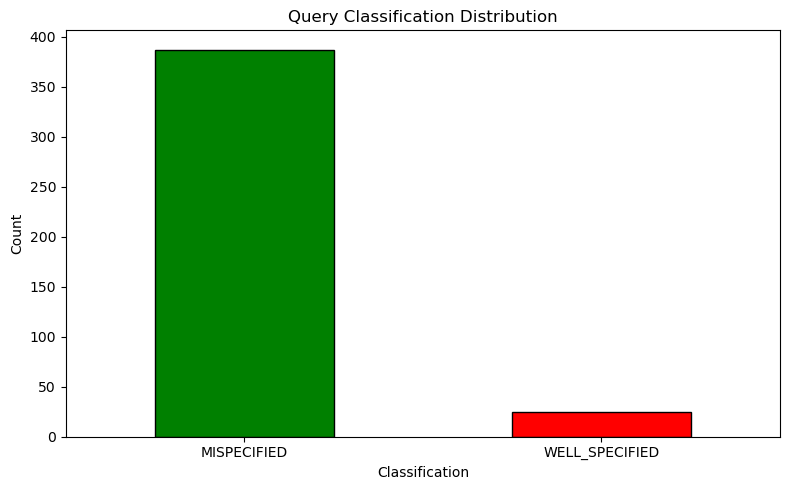

In [22]:
# Summary of classification results
print("\n" + "="*60)
print("QUERY CLASSIFICATION SUMMARY")
print("="*60)

classification_counts = results_df['classification'].value_counts()
for classification, count in classification_counts.items():
    pct = count / len(results_df) * 100
    print(f"{classification}: {count} ({pct:.1f}%)")

# Visualize
plt.figure(figsize=(8, 5))
classification_counts.plot(kind='bar', color=['green', 'red', 'gray'][:len(classification_counts)], edgecolor='black')
plt.title('Query Classification Distribution')
plt.xlabel('Classification')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
# Display examples of well-specified queries with conversation within same hour
well_specified = results_df[results_df['classification'] == 'WELL_SPECIFIED']

def get_conversation_within_hour(df_sorted, msg_idx):
    """Get all messages within same hour from a user after their query."""
    query_row = df_sorted.iloc[msg_idx]
    user_id = query_row['user_id']
    query_timestamp = query_row['message_timestamp']
    hour_cutoff = query_timestamp + timedelta(hours=1)
    
    # Find all messages from same user within the hour
    messages = []
    for i in range(msg_idx, len(df_sorted)):
        row = df_sorted.iloc[i]
        if row['user_id'] != user_id:
            continue
        if row['message_timestamp'] > hour_cutoff:
            break
        messages.append({
            'sender': row['sender'],
            'message': str(row['message']),
            'timestamp': row['message_timestamp'],
            'is_query': i == msg_idx
        })
    
    return messages

def print_query_with_hour_context(row, df_sorted, client):
    """Print user query with all conversation within the same hour."""
    user_id = row['user_id']
    msg_idx = row['msg_index']
    
    print(f"User ID: {user_id}")
    print("-"*70)
    
    messages = get_conversation_within_hour(df_sorted, msg_idx)
    
    for msg in messages:
        message_text = msg['message']
        sender = msg['sender']
        timestamp = msg['timestamp']
        
        # Use translated version if already available
        if msg['is_query']:
            translated = row['translated_question']
        else:
            translated = translate_to_english(client, message_text, model_name="gpt-4.1-mini") if len(message_text) > 2 else message_text
        
        prefix = "[USER]" if sender == 'USER' else "[BOT] "
        
        if msg['is_query']:
            print(f"\n{prefix} ({timestamp.strftime('%H:%M:%S')}): {translated}  [QUERY]")
        else:
            print(f"{prefix} ({timestamp.strftime('%H:%M:%S')}): {translated}")

print("\n" + "="*70)
print("EXAMPLES OF WELL-SPECIFIED QUERIES (with 1-hour conversation context)")
print("="*70)

for idx, (i, row) in enumerate(well_specified.head(10).iterrows()):
    print(f"\n{'━'*70}")
    print(f"EXAMPLE {idx+1}")
    print(f"{'━'*70}")
    print_query_with_hour_context(row, df_sorted, client)
    print()


EXAMPLES OF WELL-SPECIFIED QUERIES (with 1-hour conversation context)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXAMPLE 1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
User ID: 919752740930
----------------------------------------------------------------------

[USER] (17:09:07): My period's last date is 28 September, so what will be the delivery date?  [QUERY]
[BOT]  (17:09:09): Please select only from the given list.
[BOT]  (17:09:11): Now, tap a button to select the day of the month.
[USER] (17:09:21): 4
[BOT]  (17:09:23): Okay, thank you.
[BOT]  (17:09:24): Regular check-ups are necessary for your child.
[BOT]  (17:09:25): Do you go to Hamidia Hospital for a check-up after the baby is born?  
{{Yes}}  
{{No}}
[USER] (17:09:35): 1
[BOT]  (17:09:44): If you need help, please call your clinic or hospital or go there 👩🏽‍⚕️
[BOT]  (17:09:45): Please wait for my message - I will keep sending you useful tips and reminders to help you

In [27]:
# Display examples of mispecified/vague queries with conversation within same hour
mispecified = results_df[results_df['classification'] == 'MISPECIFIED']

print("\n" + "="*70)
print("EXAMPLES OF MISPECIFIED/VAGUE QUERIES (with 1-hour conversation context)")
print("="*70)

for idx, (i, row) in enumerate(mispecified.head(20).iterrows()):
    print(f"\n{'━'*70}")
    print(f"EXAMPLE {idx+1}")
    print(f"{'━'*70}")
    print_query_with_hour_context(row, df_sorted, client)
    print()


EXAMPLES OF MISPECIFIED/VAGUE QUERIES (with 1-hour conversation context)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXAMPLE 1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
User ID: 919301399765
----------------------------------------------------------------------

[USER] (02:00:43): Why do I have stomach pain?  [QUERY]
[BOT]  (02:01:06): Stomach pain can be caused by various reasons, such as gas, indigestion, or constipation. If the pain persists or is severe, you should consult a doctor. Rest at home, drink plenty of water, and eat light meals. If the pain is intense or accompanied by other symptoms like fever or vomiting, seek medical help immediately.
[USER] (02:02:45): Sometimes it happens
[BOT]  (02:03:01): Occasional stomach pain is usually caused by gas, indigestion, or constipation. If the pain occurs frequently or is severe, you should consult a doctor. It is important for your safety and health.
[USER] (02:03:55): है
[BO

In [26]:
# Save classification results
results_df.to_csv('query_classification_results.csv', index=False)
print(f"\nClassification results saved to 'query_classification_results.csv'")


Classification results saved to 'query_classification_results.csv'
